In [35]:
import pandas as pd
import geopandas as gpd

df_main = pd.read_csv("outputs/simulation_results.csv")
df_main.head()

,building_id,year,renovation_probability
0,1205,2025,0.1
1,76,2025,0.1
2,213,2025,0.4
3,218,2025,0.1
4,309,2025,0.2


In [36]:
df_info = pd.read_json("Koper_Data/buildings_info.json").rename(columns={"Building id": "building_id"})
relevant_buildings = df_info['building_id'].unique()
relevant_buildings

array([ 158,  372,  396,  458,  459,  460,  522,  654,  655,  657,  658,
        668,  670,  671,  673,  677,  680,  681,  685,  692,  693,  694,
        695,  698,  699,  701,  702,  703,  704,  705,  707,  708,  711,
        712,  715,  716,  721,  724,  727,  730,  734,  736,  738,  741,
        748,  749,  750,  753,  755,  766,  770,  772,  777,  778,  780,
        781,  785,  786,  787,  792,  797,  798,  799,  800,  803,  807,
        808,  812,  814,  816,  819,  823,  826,  828,  829,  830,  831,
        833,  839,  841,  844,  847,  851,  852,  853,  854,  856,  858,
        859,  861,  863,  865,  866,  869,  870,  871,  872,  879,  881,
        882,  885,  887,  888,  889,  891,  892,  895,  896,  897,  899,
        901,  910,  911,  916,  937,  948,  952,  961,  962,  964,  965,
        979,  981,  983,  987,  988,  992,  993,  996, 1003, 1004, 1009,
       1010, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1029, 1038, 1102,
       1103, 1104, 1106, 1108, 1112, 1115, 1116, 11

In [37]:
shapes_df = gpd.read_file("Koper_Data/building_shape_filtered.geojson").to_crs(epsg=3857)
shapes_df = shapes_df[shapes_df["building_id"].isin(relevant_buildings)]
shapes_df.head()

,building_id,geometry
0,373,"POLYGON ((1528973.436 5708104.652, 1528970.049..."
1,372,"POLYGON ((1529017.457 5708070.29, 1528996.903 ..."
2,389,"POLYGON ((1528993.081 5708138.232, 1528994.829..."
3,396,"POLYGON ((1528993.603 5708161.241, 1528991.957..."
4,391,"POLYGON ((1529012.053 5708142.08, 1529002.194 ..."


<Axes: >

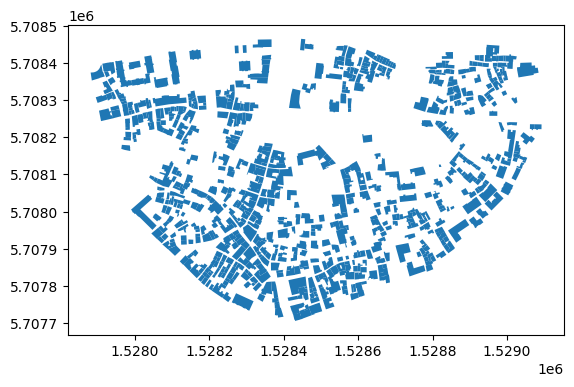

In [38]:
shapes_df.plot()

In [39]:
merged = shapes_df.merge(df_main, on="building_id", how="left")
merged['year'] = merged['year'].astype('Int64')
merged.fillna(0, inplace=True)
merged.head()

,building_id,geometry,year,renovation_probability
0,373,"POLYGON ((1528973.436 5708104.652, 1528970.049...",0,0.0
1,372,"POLYGON ((1529017.457 5708070.29, 1528996.903 ...",0,0.0
2,389,"POLYGON ((1528993.081 5708138.232, 1528994.829...",2026,0.1
3,389,"POLYGON ((1528993.081 5708138.232, 1528994.829...",2027,0.1
4,389,"POLYGON ((1528993.081 5708138.232, 1528994.829...",2028,0.1


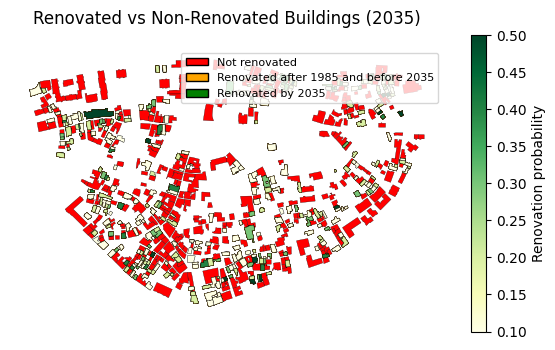

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

target_year = 2035

# Keep duplicates for renovated
renovated = merged[merged["year"] == target_year]

# Renovated recently
renovated_recently = merged[(merged["year"] >= target_year - 50) & (merged["year"] < target_year)]

# Drop duplicates only for not renovated
not_renovated = merged[(merged["year"] < target_year - 50)] \
    .drop_duplicates(subset="building_id")

# Ensure numeric values for colormap
renovated["renovation_probability"] = pd.to_numeric(
    renovated["renovation_probability"], errors="coerce"
)

fig, ax = plt.subplots(figsize=(7, 7))

# Not renovated = fixed red
not_renovated.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.2,
)

# renovated recently = fixed orange
renovated_recently.plot(
    ax=ax,
    color="orange",
    edgecolor="black",
    linewidth=0.2,
)

# Renovated = colored by renovation_probability
renovated.plot(
    ax=ax,
    column="renovation_probability",
    cmap="YlGn",
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    legend_kwds={
        "label": "Renovation probability",
        "shrink": 0.55,   # smaller colorbar
    },
)

legend_handles = [
    Patch(facecolor="red", edgecolor="black", label=f"Not renovated"),
    Patch(facecolor="orange", edgecolor="black", label=f"Renovated after {target_year - 50} and before {target_year}"),
    Patch(facecolor="green", edgecolor="black", label=f"Renovated by {target_year}")
]
ax.legend(handles=legend_handles, loc="best", fontsize=8)

ax.set_axis_off()
ax.set_title(f"Renovated vs Non-Renovated Buildings ({target_year})")
plt.show()